# 3. CNN - 특징 감지하기

# 3.0 GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


필터 = 합성곱 = convolution

## 3.1 합성곱

데이터 준비

In [ ]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

# 데이터셋
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# 데이터 로더
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

모델 클래스 정의

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            # in (1,28,28) -> out (64,28,28)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # in (64,28,28) -> out (64,14,14)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            # in (64,14,14) -> out (64,12,12)
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU(),
            # in (64,12,12) -> out (64,6,6)
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(64*6*6, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        # contiguous 등의 차이가 있지만, 일단 reshape와 같다고 보면 될 듯...배치 외에는 한 줄로 편다...
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

훈련 함수 정의

In [ ]:
def train(model, loader, device, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Train Epoch: {epoch} -- Loss: {loss.item():.6f}")

def test(model, loader, device):
    model.eval()
    with torch.no_grad():
        correct, total = 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # 인덱스, 최댓값 반환, dim=1
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        print(f"Accuracy of the network on the 10,000 test images: {100 * correct / total}%")

모델, 손실함수, 최적화 인스턴스 만들기

In [10]:
model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

학습하고 테스트

In [11]:
iters = 51
for epoch in range(1, iters):
    train(model, train_loader, device, optimizer, criterion, epoch)

test(model, test_loader, device)

Train Epoch: 1 -- Loss: 0.419149
Train Epoch: 2 -- Loss: 0.383603
Train Epoch: 3 -- Loss: 0.352774
Train Epoch: 4 -- Loss: 0.324733
Train Epoch: 5 -- Loss: 0.269703
Train Epoch: 6 -- Loss: 0.300091
Train Epoch: 7 -- Loss: 0.285332
Train Epoch: 8 -- Loss: 0.283477
Train Epoch: 9 -- Loss: 0.245766
Train Epoch: 10 -- Loss: 0.236835
Train Epoch: 11 -- Loss: 0.225352
Train Epoch: 12 -- Loss: 0.181767
Train Epoch: 13 -- Loss: 0.180185
Train Epoch: 14 -- Loss: 0.187859
Train Epoch: 15 -- Loss: 0.174768
Train Epoch: 16 -- Loss: 0.173997
Train Epoch: 17 -- Loss: 0.175829
Train Epoch: 18 -- Loss: 0.183645
Train Epoch: 19 -- Loss: 0.178289
Train Epoch: 20 -- Loss: 0.178777
Train Epoch: 21 -- Loss: 0.124586
Train Epoch: 22 -- Loss: 0.134225
Train Epoch: 23 -- Loss: 0.166245
Train Epoch: 24 -- Loss: 0.133708
Train Epoch: 25 -- Loss: 0.164481
Train Epoch: 26 -- Loss: 0.116914
Train Epoch: 27 -- Loss: 0.142308
Train Epoch: 28 -- Loss: 0.115587
Train Epoch: 29 -- Loss: 0.108935
Train Epoch: 30 -- Loss

모델 분석

In [12]:
from torchsummary import summary

summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
              ReLU-2           [-1, 64, 28, 28]               0
         MaxPool2d-3           [-1, 64, 14, 14]               0
            Conv2d-4           [-1, 64, 12, 12]          36,928
              ReLU-5           [-1, 64, 12, 12]               0
         MaxPool2d-6             [-1, 64, 6, 6]               0
            Linear-7                  [-1, 128]         295,040
            Linear-8                   [-1, 10]           1,290
Total params: 333,898
Trainable params: 333,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.02
Params size (MB): 1.27
Estimated Total Size (MB): 2.30
----------------------------------------------------------------


## 3.5 말과 사람을 구별하는 CNN 만들기

데이터셋 받아서 풀기

In [26]:
training_dir = "horse-or-human/training"
validation_dir = "horse-or-human/validation"

In [27]:
import urllib.request
import zipfile

url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"
file_name = "horse-or-human.zip"
urllib.request.urlretrieve(url, file_name)

with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(training_dir)

url = "https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip"
file_name = "validation-horse-or-human.zip"
urllib.request.urlretrieve(url, file_name)

with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(validation_dir)

데이터셋 준비

In [58]:
train_trasform = transforms.Compose([
    # 이건 빨리하려고 줄인다고...
    transforms.Resize((150, 150)),
    # 데이터 수가 적고, 포즈나 구도가 한정적이니까 데이터를 변형해서 비슷한 효과를 노린다...
    transforms.RandomHorizontalFlip(),
    # 왼쪽 또는 오른쪽으로 20도까지 무작위 회전
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        # 수직 또는 수평으로 20%까지 무작위 이동
        translate=(0.2, 0.2),
        # 20%까지 무작위 확대 또는 축소
        scale=(0.8, 1.2),
        shear=20
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
val_trasform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(training_dir, transform=train_trasform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = datasets.ImageFolder(validation_dir, transform=val_trasform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

말-사람 데이터셋 CNN 클래스

In [59]:
import torch.nn.functional as F

class HorseHumanCNN(nn.Module):
    def __init__(self):
        super(HorseHumanCNN, self).__init__()
        # 입력 채널 3 (RGB), 출력 채널 16, 커널 크기 3, 패딩 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 18 * 18, 512)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(512, 1)
    
    def forward(self, x):
        # 입력 (3, 150, 150) -> conv1 -> (16, 150, 150) -> pool -> (16, 75, 75)
        x = self.pool(F.relu(self.conv1(x)))
        # 입력 (16, 75, 75) -> conv2 -> (32, 75, 75) -> pool -> (32, 37, 37)
        x = self.pool(F.relu(self.conv2(x)))
        # 입력 (32, 37, 37) -> conv3 -> (64, 37, 37) -> pool -> (64, 18, 18)
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 18 * 18)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x

모델, 손실 함수와 최적화 함수

In [60]:
model = HorseHumanCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

훈련, 테스트 함수

In [61]:
# 이거부터 고쳐야 함...
def test(model, loader, device, mode):
    model.eval()
    with torch.no_grad():
        correct, total = 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).view(-1)
            # 인덱스, 최댓값 반환, dim=1
            predicted = outputs > 0.5
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        print(f"{mode} Set Accuracy: {100 * correct / total}%")

def train(model, train_loader, val_loader, device, optimizer, criterion, epochs):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, lables in train_loader:
            images, lables = images.to(device), lables.to(device).float()
            optimizer.zero_grad()
            output = model(images).view(-1)
            # 여기서 loss 계산을 위해서 labels를 float으로...
            loss = criterion(output, lables)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch: {epoch + 1} -- Loss: {running_loss / len(train_loader)}")

        # train의 정확도를 다시 테스트?
        test(model, train_loader, device, mode="Train")
        # 그리고는 validation의 정확도 테스트?
        test(model, val_loader, device, mode="Validation")


In [62]:
train(model, train_loader, val_loader, device, optimizer, criterion, epochs=15)

Epoch: 1 -- Loss: 0.6213557693091306
Train Set Accuracy: 74.4888023369036%
Validation Set Accuracy: 51.5625%
Epoch: 2 -- Loss: 0.5108792574116678
Train Set Accuracy: 78.77312560856865%
Validation Set Accuracy: 55.46875%
Epoch: 3 -- Loss: 0.39124647640820703
Train Set Accuracy: 83.25219084712755%
Validation Set Accuracy: 64.453125%
Epoch: 4 -- Loss: 0.4067788589181322
Train Set Accuracy: 82.47322297955209%
Validation Set Accuracy: 56.640625%
Epoch: 5 -- Loss: 0.2997048870857918
Train Set Accuracy: 86.27069133398247%
Validation Set Accuracy: 53.90625%
Epoch: 6 -- Loss: 0.2302065228648258
Train Set Accuracy: 89.28919182083739%
Validation Set Accuracy: 57.03125%
Epoch: 7 -- Loss: 0.19828998892934938
Train Set Accuracy: 94.9367088607595%
Validation Set Accuracy: 71.09375%
Epoch: 8 -- Loss: 0.21581874042749405
Train Set Accuracy: 94.15774099318404%
Validation Set Accuracy: 58.203125%
Epoch: 9 -- Loss: 0.139530797065659
Train Set Accuracy: 93.1840311587147%
Validation Set Accuracy: 53.125%
Ep

픽사베이 이미지 테스트

Labels: 1


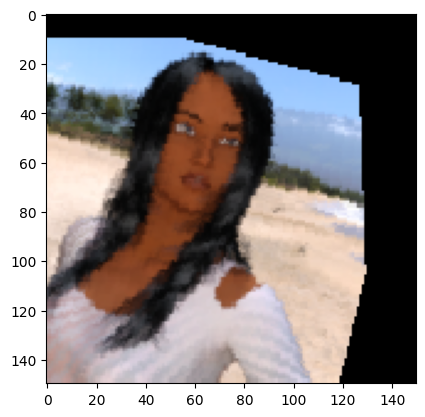

In [63]:
# 모델 라벨이 어떻게 학습되었지?
import matplotlib.pyplot as plt

images, labels = train_dataset[968]
plt.imshow(images.permute(1, 2, 0) * 0.5 + 0.5)  # pytorch CHW -> matplotlib HWC, 정규화 해제
print(f"Labels: {labels}")

In [64]:
import os
from PIL import Image

my_img_dir = "horse-or-human/my"
my_imgs = os.listdir(my_img_dir)

def predict(model, img_path, transform, device):
    model.eval()
    # 이미지 열어서, 아닌 경우 RGB로 변환
    image = Image.open(img_path).convert("RGB")
    # unsqueeze(0) - 0 차원에 배치 차원 추가...
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        predicted = output > 0.5
        label = "사람" if predicted.item() == 1 else "말"
        print(img_path)
        print(f"Predicted: {label} for image {os.path.basename(img_path)}")
        print(output)

for img in my_imgs:
    predict(model, os.path.join(my_img_dir, img), train_trasform, device)

horse-or-human/my\1857643-freedom-4782870_640.jpg
Predicted: 말 for image 1857643-freedom-4782870_640.jpg
tensor([[0.0179]], device='cuda:0')
horse-or-human/my\artbyfjord-horse-8472924_640.jpg
Predicted: 말 for image artbyfjord-horse-8472924_640.jpg
tensor([[8.9873e-08]], device='cuda:0')
horse-or-human/my\caropat-horse-8104389_640.jpg
Predicted: 사람 for image caropat-horse-8104389_640.jpg
tensor([[0.9932]], device='cuda:0')
horse-or-human/my\hongquan7749-girl-4809433_640.jpg
Predicted: 사람 for image hongquan7749-girl-4809433_640.jpg
tensor([[0.8919]], device='cuda:0')
horse-or-human/my\jpeter2-old-man-1086437_640.jpg
Predicted: 말 for image jpeter2-old-man-1086437_640.jpg
tensor([[0.1196]], device='cuda:0')
horse-or-human/my\photo-graphe-horse-1804425_640.jpg
Predicted: 사람 for image photo-graphe-horse-1804425_640.jpg
tensor([[0.8488]], device='cuda:0')
horse-or-human/my\publicdomainpictures-medieval-276019_640.jpg
Predicted: 말 for image publicdomainpictures-medieval-276019_640.jpg
tensor([